# In this class... 

    - Tables and DataFrames
    - Importing data from OpenML
    - Graphs 
    - Trimmed mean

---
  

In [1]:
%matplotlib inline

In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 

from pathlib import Path
print('Imported libraries')


Imported libraries


# Data Organization and Visualization

## Tables

In [ ]:
# Columns: features

fruits = {'type': ['Apple', 'Strawberry', 'Banana'], 'peel': [1, 0, 1], 'weight (g)': [200, 15, 150]}
df_fruits = pd.DataFrame(data=fruits) # Generates a Data Frame (table) from our dict

df_fruits


,type,peel,weight (g)
0,Apple,1,200
1,Strawberry,0,15
2,Banana,1,150


### Bigger Datasets

In [ ]:
from sklearn.datasets import fetch_openml

# Beer
births = fetch_openml('US-Births', as_frame=True)
df_births = pd.DataFrame(data=births['data'])
df_births

,id_series,date,value_0,time_step
0,0,1969-01-01,8486,0
1,0,1969-01-02,9002,1
2,0,1969-01-03,9542,2
3,0,1969-01-04,8960,3
4,0,1969-01-05,8390,4
...,...,...,...,...
7300,0,1988-12-27,11528,7300
7301,0,1988-12-28,11847,7301
7302,0,1988-12-29,11704,7302
7303,0,1988-12-30,11837,7303


In [ ]:
# Treepits
avocado = fetch_openml('avocado_sales', as_frame=True)
df_avocado = pd.DataFrame(data=avocado['data'])
df_avocado

,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,month,day
0,39993186.04,12508937.27,13315901.42,1761343.08,12407004.27,9967538.34,1887772.28,551693.65,conventional,2016,TotalUS,7,3
1,35567568.43,11457080.38,11677528.00,1266433.97,11166526.08,8984513.63,1727668.80,454343.65,conventional,2016,TotalUS,7,10
2,32656123.63,10320463.27,10628872.60,953631.47,10753156.29,8737861.29,1624816.27,390478.73,conventional,2016,TotalUS,7,17
3,32339377.09,10331314.28,10795751.15,947964.05,10264347.61,8315738.70,1561208.69,387400.22,conventional,2016,TotalUS,7,24
4,38010426.16,12623188.50,10988734.57,859889.81,13538613.28,10041243.95,3119708.27,377661.06,conventional,2017,TotalUS,7,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18244,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.00,organic,2018,WestTexNewMexico,2,4
18245,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.00,organic,2018,WestTexNewMexico,1,28
18246,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.00,organic,2018,WestTexNewMexico,1,21
18247,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.00,organic,2018,WestTexNewMexico,1,14


## Graphs

We are also using this example to see the difference between `date_birth = df_births['date']` and ``date_birth = pd.to_datetime(df_births['date'])``

In the first one, we are treating dates as strings, making it harder and more time-intensive to plot, while in the second one, we are treating dates as integers.



In [ ]:
# ~ 3 to 4 minutes to run and plot [commented code to avoid running it]

# date_birth = df_births['date']
# num = df_births['value_0']
# fig, ax = plt.subplots()
# ax.plot(date_birth, num)

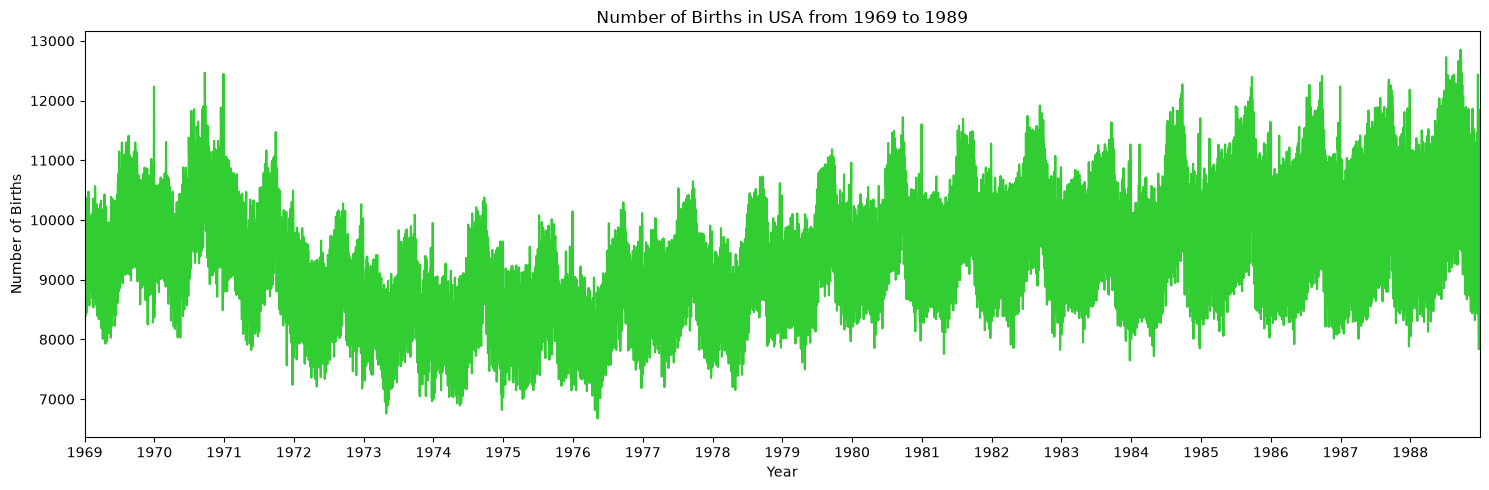

In [ ]:
# Less than 1 second (treating date as integers)
date_birth = pd.to_datetime(df_births['date'])
num = df_births['value_0']

first_date = date_birth[0]
# Extra, if I want to know the last item, I have to use iloc[-1] (not just [-1] as I usually would in numpy!)
last_date = date_birth.iloc[-1]


import matplotlib.dates as mdates 

fig, ax = plt.subplots(figsize=(15,5))

ax.plot(date_birth, num, color='limegreen')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Births')
ax.set_title('Number of Births in USA from 1969 to 1989')

ax.set_xlim(first_date, last_date)
ax.xaxis.set_major_locator(mdates.YearLocator(1)) # One Year per tick

fig.tight_layout()

In [ ]:
avocado.DESCR

'Historical data on avocado prices and sales volume in multiple US markets. For this version Date column is dropped and month and day information in kept.\n\nDownloaded from openml.org.'

In [ ]:
df_avocado.keys()

Index(['Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags',
       'Large Bags', 'XLarge Bags', 'type', 'year', 'region', 'month', 'day'],
      dtype='str')

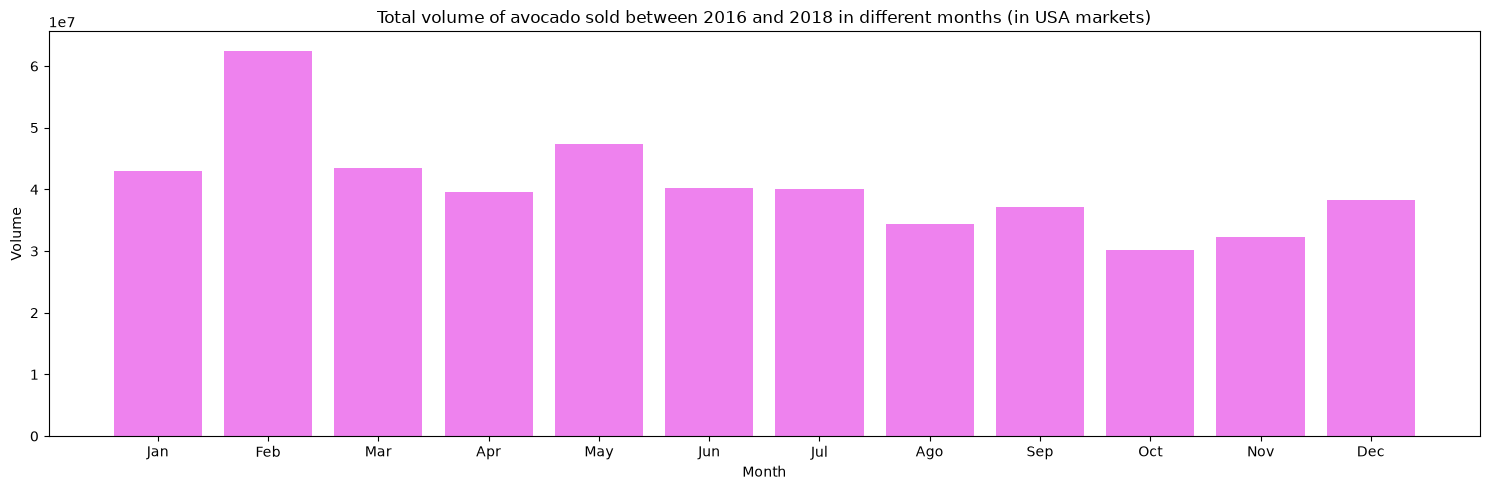

In [ ]:
from matplotlib.ticker import MaxNLocator

month = df_avocado['month']
volume = df_avocado['Total Volume']

fig2, ax2 = plt.subplots(figsize=(15,5))

ax2.bar(month, volume, color='violet')
ax2.set_xlabel('Month')
ax2.set_ylabel('Volume') # It should have units but they aren't specified in the original dataset :(
ax2.set_title('Total volume of avocado sold between 2016 and 2018 in different months (in USA markets)')

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dec']
ax2.set_xticks(range(1, 13), labels=month_names)

fig2.tight_layout()#

In [3]:
# Now we are taking data from another .csv file. Although I'm in a Jupyter Notebook, I'll write the code also for a .py 

try: 
    actual_root = Path(__file__).resolve().parent
except NameError:
    actual_root = Path.cwd()

data_dir = actual_root.parent / 'data'
data_dir

WindowsPath('c:/Users/jorge/Desktop/statistics-and-ml-playground/1_practical_statistics/data')

In [4]:
medals = pd.read_csv(data_dir/'medals.csv')
medals

,Country,Gold Medal,Silver Medal,Bronze Medal,Total,Rank By Total
0,United States of America,39,41,33,113,1
1,People's Republic of China,38,32,18,88,2
2,Japan,27,14,17,58,5
3,Great Britain,22,21,22,65,4
4,ROC,20,28,23,71,3
...,...,...,...,...,...,...
88,Ghana,0,0,1,1,77
89,Grenada,0,0,1,1,77
90,Kuwait,0,0,1,1,77
91,Republic of Moldova,0,0,1,1,77


In [5]:
gold = medals['Gold Medal']
tot = medals['Total']


mean_gold = gold.mean()
mean_tot = tot.mean()

std_gold = gold.std()
std_tot = tot.std()

# I'm using gold.mean() instead of np.mean(gold) because Pandas already has an optimize method in C for computing the mean!

In [6]:
# Now lets get the z-score
z_gold = (gold-mean_gold) / std_gold
z_tot = (tot - mean_tot) / std_tot

z_gold.max()

np.float64(5.0329984217042005)

In [7]:
medals['Country'][1]


"People's Republic of China"

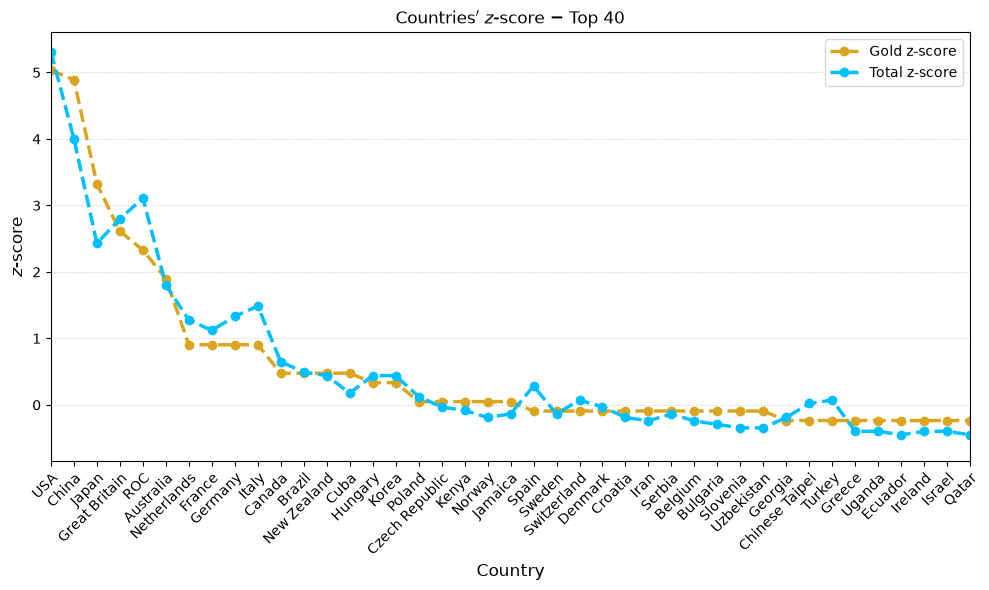

In [8]:
# Changing names on countries that are too long 
medals['Country'] = medals['Country'].replace({
    "United States of America": 'USA',
    "People's Republic of China": 'China',
    'United Kingdom': 'UK',
    'Republic of Korea': 'Korea',
    'Islamic Republic of Iran': 'Iran'
})


country = medals['Country']

# And a simple graph:

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(country, z_gold, color = 'goldenrod', lw = 2.5, ls='--', marker='.', markersize=12, label='Gold z-score')
ax.plot(country, z_tot, color = 'deepskyblue', lw = 2.5, ls='--', marker='.', markersize=12, label='Total z-score')

ax.set_xlabel(r'Country',  fontsize=12)   
ax.set_ylabel(r'$z$-score', fontsize = 12)


# This is how you rotate the x-label
ax.tick_params(axis='x', labelrotation=45)
plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')

max_countries = 40

ax.grid(axis='y', linestyle=':', alpha=0.6) 
ax.set_xlim(0, max_countries)
ax.set_title(f'Countries$\'$ $z$-score $-$ Top {max_countries}')

ax.legend(loc='upper right')
plt.tight_layout()


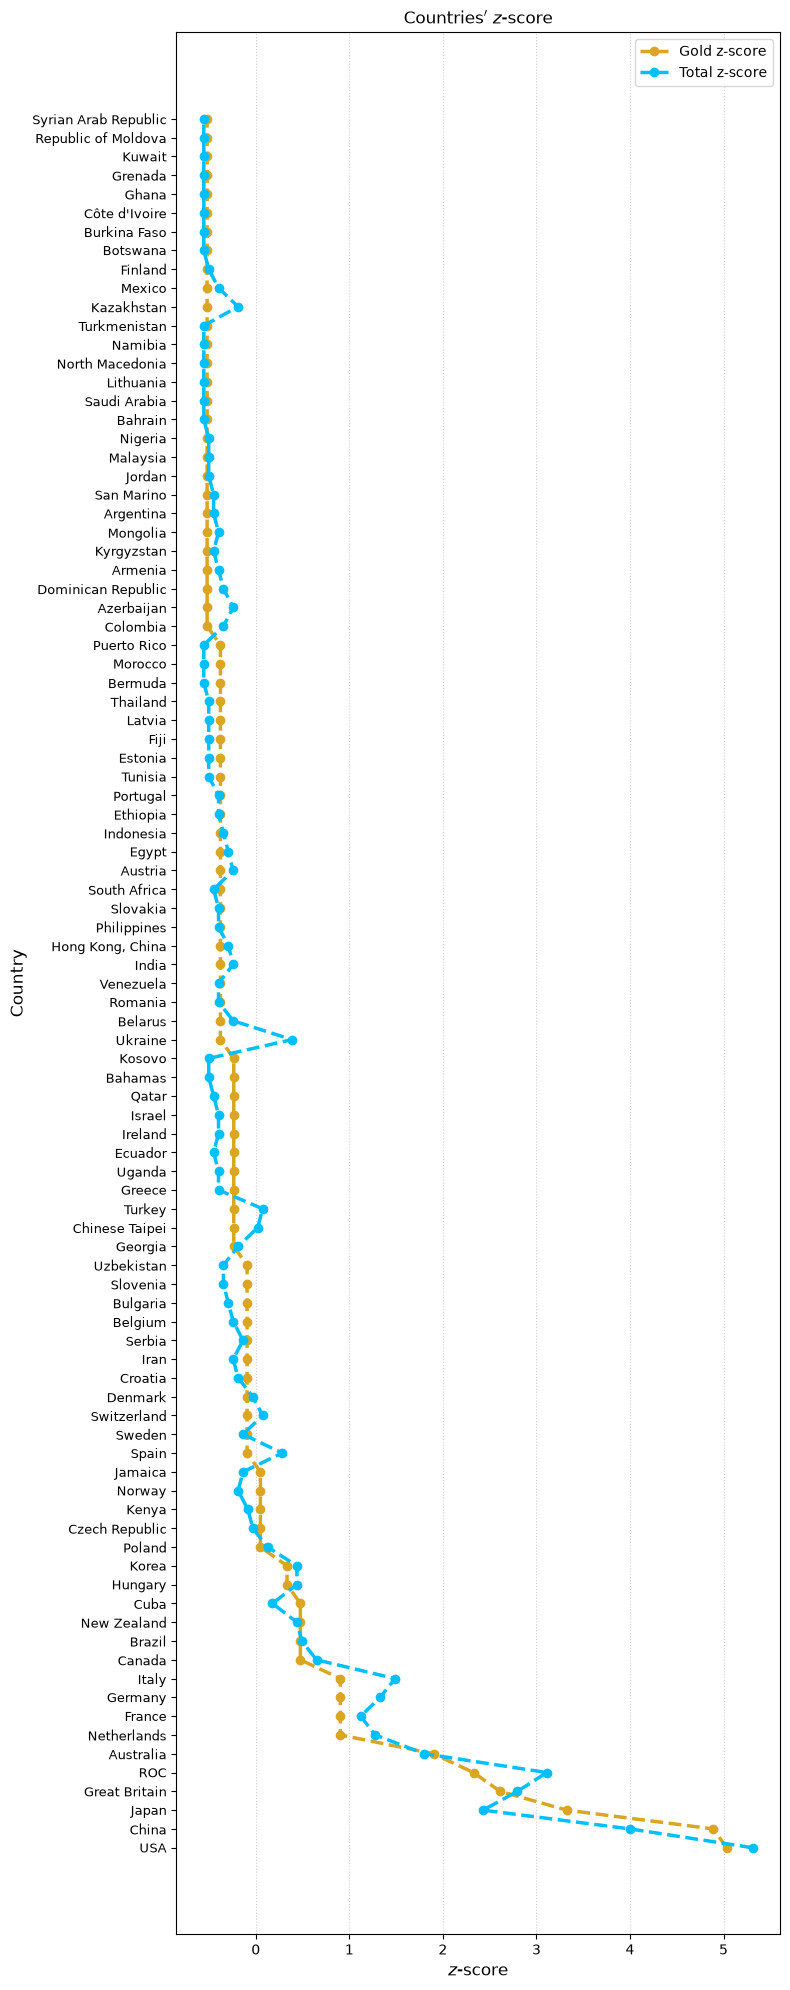

In [9]:
fig, ax = plt.subplots(figsize=(8, 20))  # Taller than wider

# Inverted order
ax.plot(z_gold, country, color='goldenrod', lw=2.5, ls='--', marker='.', markersize=12, label='Gold z-score')
ax.plot(z_tot, country, color='deepskyblue', lw=2.5, ls='--', marker='.', markersize=12, label='Total z-score')

ax.set_xlabel(r'$z$-score', fontsize=12)
ax.set_ylabel(r'Country', fontsize=12)   
ax.tick_params(axis='y', labelsize=9) 
ax.set_title('Countries$\'$ $z$-score')
ax.grid(axis='x', linestyle=':', alpha=0.6) 
ax.legend(loc='upper right')

plt.tight_layout()

## Trimmed mean

In [ ]:
# Useful to avoid outliers in the mean
from scipy.stats import trim_mean
out_perc = 0.05 # Outliers percentage
trim_gold = trim_mean(gold, out_perc)

In [ ]:
# It can also be done for just one of the edges of the data (e.g. the highest values)
# and using just pandas!

upper_quantile = gold.quantile(0.95) # Obtain the uppest 5%
trim_gold_upper = gold[gold < upper_quantile].mean()

np.float64(2.2045454545454546)